# 28 — Qui choisit le catalogue choisit l'indice

Le dépôt répète depuis le premier jour une réserve qu'il n'a jamais chiffrée :

> La discrétisation en points de vue est un **choix politique**. Qui définit les modalités
> définit l'index. Découper l'espace des opinions en 4, 40 ou 400 catégories change la valeur
> mesurée, et ce découpage n'est pas un acte technique neutre. → [IDE](../ide.md)

C'est vrai, et cela ne dit rien. *De combien* change-t-elle ? Assez pour rendre un plancher
arbitraire, ou assez peu pour qu'un régulateur puisse s'en accommoder ? Personne ne l'avait
mesuré, et [le chapitre 26](26_indice_mesure.md) fournit désormais de quoi le faire : 58 549
journées-utilisateur réelles, composition connue rubrique par rubrique.

Ce chapitre mesure trois choses distinctes que la réserve confondait : le **niveau** de
l'indice, la **part sous le plancher**, et l'**ordre** entre lecteurs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from ide.ebnerd import catalogue_size, load_digest, section_counts
from ide.entropy import coarsen_catalogue, effective_viewpoints
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

digest = load_digest()
CATALOGUE = catalogue_size(digest)
sections, occurrences = section_counts(digest, "section")
tones, _ = section_counts(digest, "tone")
weights = occurrences / occurrences.sum()

print(f"{occurrences.sum():,} journées-utilisateur, {len(sections):,} compositions distinctes"
      .replace(",", " "))
print(f"catalogue déclaré : {CATALOGUE} rubriques ; second axe : {tones.shape[1]} tonalités")

58 549 journées-utilisateur  53 820 compositions distinctes
catalogue déclaré : 26 rubriques ; second axe : 3 tonalités


## 1. Trois grandeurs, et elles ne se comportent pas de la même façon

On fabrique des catalogues plus grossiers en gardant les rubriques les plus servies et en
agrégeant le reste. Le regroupement se décide sur le **total du corpus**, jamais journée par
journée : un découpage qui dépendrait de l'observation ne serait pas un catalogue.

On ajoute un second axe d'étiquetage — la **tonalité** déclarée de chaque article, négative,
neutre ou positive — qui est plus proche d'un point de vue qu'une rubrique thématique.

In [2]:
def indice(matrix, catalogue):
    total = matrix.sum(1, keepdims=True).astype(float)
    shares = np.divide(matrix, total, out=np.zeros(matrix.shape, dtype=float), where=total > 0)
    logs = np.log2(shares, out=np.zeros_like(shares), where=shares > 0)
    return -(shares * logs).sum(1) / np.log2(catalogue)


def quantile(values, probability=0.5):
    order = np.argsort(values)
    return float(values[order][np.searchsorted(np.cumsum(weights[order]), probability)])


def concordance(left, right):
    # Corrélation de rang, journée par journée — chaque composition pesée de sa fréquence.
    return float(stats.spearmanr(np.repeat(left, occurrences),
                                 np.repeat(right, occurrences)).statistic)


reference = indice(sections, CATALOGUE)
catalogues = [("rubriques complètes", sections, CATALOGUE)]
catalogues += [(f"{keep - 1} rubriques + reste", coarsen_catalogue(sections, keep), keep)
               for keep in (12, 6, 3)]
catalogues += [("tonalité", tones, tones.shape[1])]

mesures = {}
print("catalogue              k   médiane   vues eff.   sous 0,40   sous 0,50    ρ de rang")
for nom, matrice, taille in catalogues:
    valeurs = indice(matrice, taille)
    mediane = quantile(valeurs)
    mesures[nom] = {
        "k": taille, "valeurs": valeurs, "médiane": mediane,
        "sous_40": float(weights[valeurs < 0.40].sum()),
        "sous_50": float(weights[valeurs < 0.50].sum()),
        "rho": concordance(reference, valeurs),
    }
    print(f"{nom:<21} {taille:>3}    {mediane:.3f}      {effective_viewpoints(mediane, taille):>5.2f}"
          f"       {mesures[nom]['sous_40']:.3f}       {mesures[nom]['sous_50']:.3f}"
          f"       {mesures[nom]['rho']:+.3f}")

catalogue              k   médiane   vues eff.   sous 0,40   sous 0,50    ρ de rang
rubriques complètes    26    0.498       5.07       0.137       0.507       +1.000
11 rubriques + reste   12    0.654       5.07       0.047       0.109       +1.000
5 rubriques + reste     6    0.860       4.67       0.021       0.030       +0.911
2 rubriques + reste     3    0.924       2.76       0.015       0.031       -0.093
tonalité                3    0.881       2.63       0.013       0.040       +0.155


**Le niveau n'a aucun sens absolu.** Le même corpus vaut $0{,}50$ sur vingt-six rubriques et
$0{,}92$ sur trois. Un plancher chiffré sans son catalogue ne veut rien dire : à $0{,}40$, il
écarte 13,7 % des journées sur le catalogue complet et 1,5 % sur le catalogue à trois modalités.
**Le même plancher passe de contraignant à décoratif.**

**L'ordre, lui, résiste — jusqu'à un point.** Passer de vingt-six rubriques à douze ne change
strictement rien au classement des lecteurs ($\rho = 1{,}000$). À six, il tient encore
($0{,}911$). À trois, il **disparaît** ($-0{,}09$).

## 2. Pourquoi l'ordre tient si bien, puis plus du tout

In [3]:
poids_rubriques = sections.sum(0) / sections.sum()
rang = np.argsort(-poids_rubriques)
print("part du corpus servie par les rubriques les plus fréquentes :")
for seuil in (2, 5, 11):
    print(f"  les {seuil:>2} premières : {poids_rubriques[rang[:seuil]].sum():.3f}")

for keep in (12, 6, 3):
    queue = rang[keep - 1:]
    fusionnées = (sections[:, queue] > 0).sum(1) >= 2
    print(f"\ncatalogue à {keep:>2} : journées dont le regroupement fusionne au moins deux "
          f"rubriques : {weights[fusionnées].sum():.3f}")

part du corpus servie par les rubriques les plus fréquentes :
  les  2 premières : 0.521
  les  5 premières : 0.886
  les 11 premières : 0.998

catalogue à 12 : journées dont le regroupement fusionne au moins deux rubriques : 0.001

catalogue à  6 : journées dont le regroupement fusionne au moins deux rubriques : 0.645

catalogue à  3 : journées dont le regroupement fusionne au moins deux rubriques : 0.948


La réponse est banale et elle décide de tout : **les quinze rubriques les plus rares ne servent
presque rien.** Regrouper la queue ne touche qu'une journée sur mille, donc ne change pas l'ordre.
Descendre à six force en revanche la fusion sur deux tiers des journées, et descendre à trois
regroupe des rubriques massives — c'est là que le classement se défait.

## 3. Un regroupement quelconque n'est pas un regroupement

Si seule la *taille* du catalogue comptait, n'importe quel découpage en six classes vaudrait le
découpage par fréquence. On le vérifie.

In [4]:
generator = np.random.default_rng(20260826)
medianes, parts, rhos = [], [], []
for _ in range(20):
    tirage = generator.integers(0, 6, size=CATALOGUE)
    mélange = np.column_stack([sections[:, tirage == groupe].sum(1) for groupe in range(6)])
    valeurs = indice(mélange, 6)
    medianes.append(quantile(valeurs))
    parts.append(float(weights[valeurs < 0.40].sum()))
    rhos.append(concordance(reference, valeurs))

aléatoire = {"médiane": float(np.mean(medianes)), "rho": float(np.mean(rhos)),
             "sous_40": float(np.mean(parts))}
print(f"regroupement par fréquence, k = 6 : médiane {mesures['5 rubriques + reste']['médiane']:.3f}"
      f"   ρ = {mesures['5 rubriques + reste']['rho']:.3f}")
print(f"regroupement aléatoire,   k = 6 : médiane {np.mean(medianes):.3f} ± {np.std(medianes):.3f}"
      f"   ρ = {np.mean(rhos):.3f} ± {np.std(rhos):.3f}")

regroupement par fréquence, k = 6 : médiane 0.860   ρ = 0.911
regroupement aléatoire,   k = 6 : médiane 0.682 ± 0.093   ρ = 0.769 ± 0.098


Deux catalogues de **même taille** rendent des indices différents de plus de deux dixièmes et des
classements dont la concordance passe de $0{,}91$ à $0{,}77$. La taille du catalogue ne suffit
donc pas à le spécifier : **il faut le publier en entier**.

## 4. Une rubrique n'est pas un point de vue, et cela se mesure maintenant

Le [chapitre 26](26_indice_mesure.md) posait cette réserve sans la chiffrer. Les deux axes
d'étiquetage disponibles — la rubrique thématique et la tonalité — permettent de la mesurer.

In [5]:
tonalité = indice(tones, tones.shape[1])
print(f"concordance des deux axes : ρ = {concordance(reference, tonalité):+.3f}")
print(f"  diversité de rubriques, médiane : {quantile(reference):.3f}")
print(f"  diversité de tonalités, médiane : {quantile(tonalité):.3f}")

haute_rubrique = reference >= quantile(reference, 0.75)
print(f"\nparmi le quart le plus divers en rubriques, part également dans le quart le plus "
      f"divers en tonalité : "
      f"{weights[haute_rubrique & (tonalité >= quantile(tonalité, 0.75))].sum() / weights[haute_rubrique].sum():.3f}")
print("(un axe qui n'apprendrait rien de l'autre donnerait 0,25)")

concordance des deux axes : ρ = +0.155
  diversité de rubriques, médiane : 0.498
  diversité de tonalités, médiane : 0.881

parmi le quart le plus divers en rubriques, part également dans le quart le plus divers en tonalité : 0.238
(un axe qui n'apprendrait rien de l'autre donnerait 0,25)


**Les deux axes mesurent presque des choses indépendantes** ($\rho = +0{,}16$). Un lecteur peut
recevoir toutes les rubriques du journal sur un ton uniformément négatif, ou une seule rubrique
dans les trois tonalités. La « diversité exposée » n'est pas une grandeur : c'est une grandeur
**par axe déclaré**.

## 5. La figure

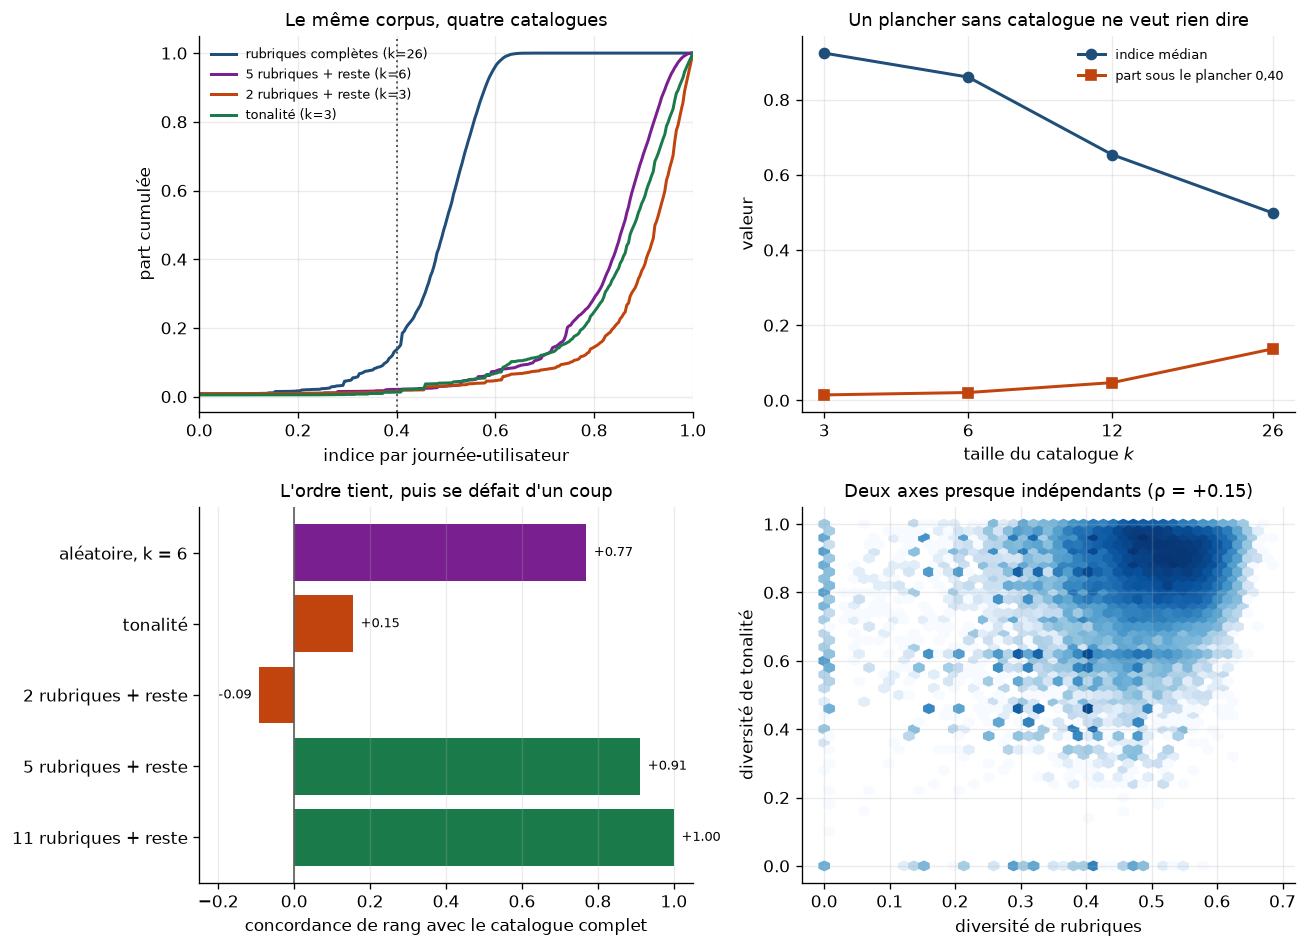

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
grille = np.linspace(0, 1, 300)
for (nom, couleur) in [("rubriques complètes", PALETTE["order"]),
                       ("5 rubriques + reste", PALETTE["field"]),
                       ("2 rubriques + reste", PALETTE["disorder"]),
                       ("tonalité", PALETTE["remedy"])]:
    valeurs = mesures[nom]["valeurs"]
    ordre = np.argsort(valeurs)
    ax.plot(grille, np.interp(grille, valeurs[ordre], np.cumsum(weights[ordre]),
                              left=0.0, right=1.0), color=couleur,
            label=f"{nom} (k={mesures[nom]['k']})")
ax.axvline(0.40, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.set(xlabel="indice par journée-utilisateur", ylabel="part cumulée", xlim=(0, 1),
       title="Le même corpus, quatre catalogues")
ax.legend(fontsize=7.5)

ax = axes[0, 1]
tailles = [mesures[nom]["k"] for nom, _, _ in catalogues[:4]]
ax.plot(tailles, [mesures[nom]["médiane"] for nom, _, _ in catalogues[:4]], marker="o",
        color=PALETTE["order"], label="indice médian")
ax.plot(tailles, [mesures[nom]["sous_40"] for nom, _, _ in catalogues[:4]], marker="s",
        color=PALETTE["disorder"], label="part sous le plancher 0,40")
ax.set(xscale="log", xlabel="taille du catalogue $k$", ylabel="valeur",
       title="Un plancher sans catalogue ne veut rien dire")
ax.minorticks_off()
ax.set_xticks(tailles)
ax.set_xticklabels([str(taille) for taille in tailles])
ax.legend(fontsize=8)

ax = axes[1, 0]
noms = [nom for nom, _, _ in catalogues[1:]] + ["aléatoire, k = 6"]
valeurs_rho = [mesures[nom]["rho"] for nom, _, _ in catalogues[1:]] + [aléatoire["rho"]]
couleurs = [PALETTE["remedy"] if valeur > 0.9 else
            PALETTE["field"] if valeur > 0.5 else PALETTE["disorder"]
            for valeur in valeurs_rho]
ax.barh(range(len(noms)), valeurs_rho, color=couleurs)
ax.axvline(0.0, color=PALETTE["neutral"], linewidth=1.0)
ax.set(yticks=range(len(noms)), yticklabels=noms, xlabel="concordance de rang avec le catalogue complet",
       xlim=(-0.25, 1.05), title="L'ordre tient, puis se défait d'un coup")
ax.grid(axis="y", alpha=0.0)
for position, valeur in enumerate(valeurs_rho):
    ax.text(valeur + (0.02 if valeur >= 0 else -0.02), position, f"{valeur:+.2f}",
            va="center", ha="left" if valeur >= 0 else "right", fontsize=8)

ax = axes[1, 1]
ax.hexbin(np.repeat(reference, occurrences), np.repeat(tonalité, occurrences),
          gridsize=45, cmap="Blues", bins="log", mincnt=1)
ax.set(xlabel="diversité de rubriques", ylabel="diversité de tonalité",
       title=f"Deux axes presque indépendants (ρ = {concordance(reference, tonalité):+.2f})")

save_figure(figure, "fig28_catalogue.png")
plt.show()

## 6. Ce que cela change

**Un plancher se publie avec son catalogue, ou ne se publie pas.** Le même corpus passe de
$0{,}50$ à $0{,}92$ selon le découpage, et la part sous $0{,}40$ de 13,7 % à 1,5 %. Un texte
réglementaire qui fixerait un seuil sans annexer la liste exacte des modalités laisserait à la
plateforme le soin de choisir sa propre note.

**La taille du catalogue ne le spécifie pas.** À six modalités, le regroupement par fréquence et
un regroupement quelconque diffèrent de deux dixièmes d'indice et de quatorze points de
concordance. C'est la **liste**, pas le nombre, qui doit figurer dans la norme.

**En dessous d'une demi-douzaine de modalités, l'indice cesse de classer.** À trois, la
concordance avec le catalogue complet tombe à $-0{,}09$ : le classement n'est pas dégradé, il est
détruit. Un catalogue trop grossier ne mesure plus rien d'utilisable, même relativement.

**Et « la diversité exposée » n'existe pas au singulier.** Rubriques et tonalité ne concordent
qu'à $\rho = 0{,}16$. Le régulateur doit dire **sur quel axe** il régule, et ce choix pèse au
moins autant que le seuil.

**Réserves.** Les catalogues grossiers sont fabriqués ici par regroupement d'un catalogue
existant, ce qui n'est pas la même chose qu'un catalogue conçu comme tel. Le corpus est celui
d'un seul journal danois, et rien ne garantit que la queue de distribution des rubriques ait
partout la même forme — or c'est elle qui explique la stabilité observée jusqu'à douze modalités.
Enfin la tonalité est une étiquette produite par un modèle, non par une rédaction.